# 07 — What the book predicts, and what the model thinks it predicts

Chapter 04 fitted a model of the queues and never asked it about prices.  But the
price moves when a queue empties, so the model does have an opinion about
direction, and it is exact: starting from queue sizes $(q_b, q_a)$, **which queue
empties first?**  That is a first-passage problem on a two-dimensional Markov
chain, and solving it gives $\mathbb{P}(\text{up} \mid q_b, q_a)$ — a prediction
about prices **that was never fitted to a price**.

Next to it sit two models that were: a logistic regression, and gradient boosting
on a wider state.  The chapter is the comparison.

Snapshots are taken on a fixed half-second clock rather than at price changes.  A
book observed immediately after a change is a freshly regenerated queue, the least
informative instant there is, and sampling only there would flatter the model.

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hfx.viz import subplots, use_style, colour_for, tick_regime
from hfx.pipeline.results import panel, curves, curve, symbol_days
use_style()
P = panel(); C = curves()
DAY = "2019-01-30"
print(f"{len(P)} symbol-days, {P.symbol.nunique()} symbols, {P.date.nunique()} dates")
L = pd.read_csv(os.path.join("..", "results", "learning.csv"))
LC = dict(np.load(os.path.join("..", "results", "learning.npz")))
print(f"{L.symbol.nunique()} symbols, {L.model.nunique()} models, "
      f"{int(L[L.scope=='common'].n.iloc[0]):,} test snapshots on the first")

84 symbol-days, 12 symbols, 7 dates
12 symbols, 6 models, 65,232 test snapshots on the first


## Ground truth: a chain we choose

Before the surface is read off real intensities it has to be right.  A symmetric
book must be a coin flip whatever the queues, and the linear solve must agree
with a plain simulation of the same chain.

In [2]:
from hfx.predict import firstpassage as fp

grid = 16
lam = np.zeros((3, grid)); lam[0, :], lam[1, :], lam[2, :] = 2.0, 1.0, 1.0
probs, steps = np.array([1.0]), np.array([1])
u, _fallback = fp.absorption_probability(lam, probs, steps, grid=grid)
print("balanced book:", np.round([u[k, k] for k in range(1, 8)], 4))
assert np.allclose([u[k, k] for k in range(1, 8)], 0.5, atol=1e-9)

rng = np.random.default_rng(0)
for start in [(3, 3), (2, 6), (6, 2)]:
    mc = fp.simulate_absorption(lam, probs, steps, start, 4000, rng=rng, grid=grid)
    print(f"  start {start}: linear solve {u[start]:.3f}   monte carlo {mc:.3f}")
    assert abs(u[start] - mc) < 4 * np.sqrt(0.25 / 4000)

balanced book: [0.5 0.5 0.5 0.5 0.5 0.5 0.5]


  start (3, 3): linear solve 0.500   monte carlo 0.493


  start (2, 6): linear solve 0.207   monte carlo 0.210


  start (6, 2): linear solve 0.793   monte carlo 0.794


## The surface, on a real book

Estimated from the training days only, and never shown an outcome.

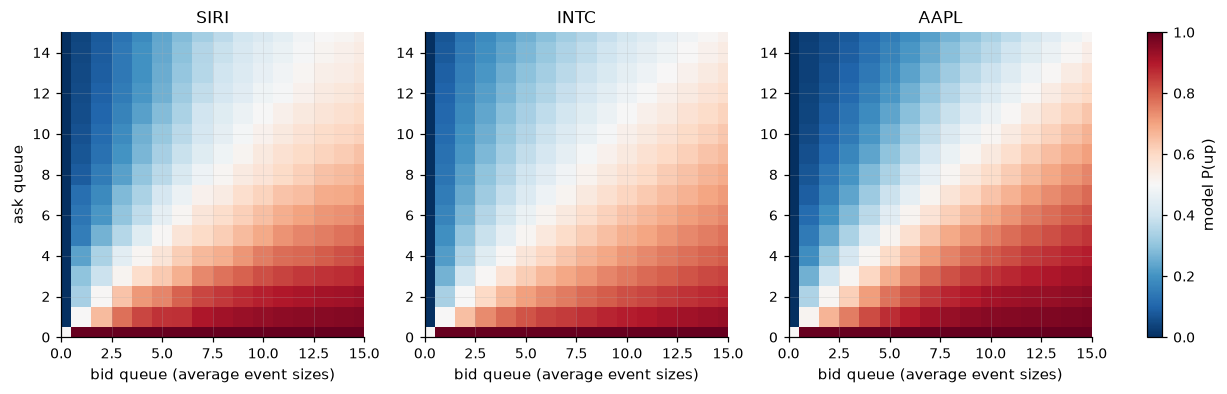

In [3]:
fig, axes = subplots(1, 3, figsize=(13, 3.6))
for ax, sym in zip(axes, ["SIRI", "INTC", "AAPL"]):
    surface = LC[f"{sym}|surface_analytic"]
    im = ax.imshow(surface.T, origin="lower", vmin=0, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_title(sym); ax.set_xlabel("bid queue (average event sizes)")
    ax.set_xlim(0, 15); ax.set_ylim(0, 15)
axes[0].set_ylabel("ask queue")
fig.colorbar(im, ax=axes, label="model P(up)", fraction=0.02)

## Does it rank states as well as something fitted to the answer?

Trained on the first five ITCH days, tested on the last two.  The split is by
day: snapshots half a second apart are near-duplicates, so a split inside a day
measures memorisation.  Everything is scored on the subset where the model's
surface is defined, so the comparison is like for like.

In [4]:
common = L[L.scope == "common"].pivot_table(index="symbol", columns="model", values="auc")
spread = P.groupby("symbol").median_spread_ticks.mean()
common.insert(0, "spread (ticks)", spread)
order = common.sort_values("spread (ticks)").index
cols = ["spread (ticks)", "analytic", "logistic_imbalance", "logistic_all", "boosted_all"]
print(common.loc[order, cols].round(3).to_string())
gap = common["logistic_all"] - common["analytic"]
print(f"\nfitted minus never-fitted: median {gap.median():+.4f}, worst {gap.abs().max():.4f}")
print(f"the never-fitted model wins outright on {(gap < 0).sum()} of {len(gap)} symbols")
assert gap.median() < 0.01 and gap.abs().max() < 0.10

model   spread (ticks)  analytic  logistic_imbalance  logistic_all  boosted_all
symbol                                                                         
CSCO             1.000     0.627               0.627         0.628        0.607
INTC             1.000     0.642               0.643         0.642        0.623
MU               1.000     0.614               0.617         0.616        0.612
SIRI             1.000     0.669               0.662         0.740        0.642
MSFT             1.143     0.582               0.585         0.586        0.586
AAPL             2.286     0.565               0.572         0.576        0.567
NFLX            12.143     0.548               0.558         0.548        0.532
TSLA            15.571     0.540               0.542         0.538        0.536
REGN            27.000     0.565               0.580         0.548        0.571
ISRG            39.429     0.570               0.559         0.549        0.541
AMZN            49.857     0.537        

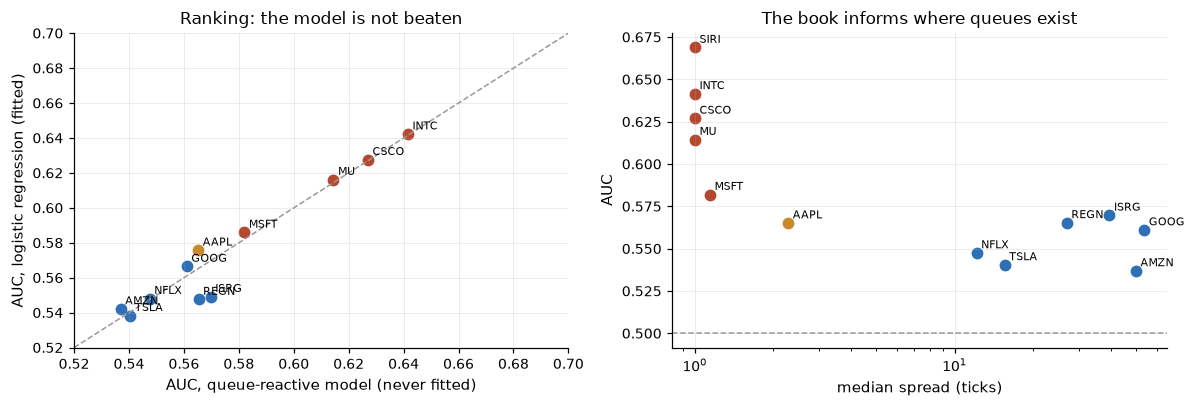

In [5]:
fig, axes = subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
for sym in order:
    x, y = common.loc[sym, "analytic"], common.loc[sym, "logistic_all"]
    ax.scatter(x, y, color=colour_for(common.loc[sym, "spread (ticks)"]), s=45)
    ax.annotate(sym, (x, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
lim = [0.52, 0.70]; ax.plot(lim, lim, color="0.6", lw=1, ls="--")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("AUC, queue-reactive model (never fitted)")
ax.set_ylabel("AUC, logistic regression (fitted)")
ax.set_title("Ranking: the model is not beaten")
ax = axes[1]
for sym in order:
    x, y = common.loc[sym, "spread (ticks)"], common.loc[sym, "analytic"]
    ax.scatter(x, y, color=colour_for(x), s=45)
    ax.annotate(sym, (x, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.axhline(0.5, color="0.6", lw=1, ls="--"); ax.set_xscale("log")
ax.set_xlabel("median spread (ticks)"); ax.set_ylabel("AUC")
ax.set_title("The book informs where queues exist")
plt.tight_layout()

## But it does not know *how much*

Ranking is not probability.  The calibration curve puts what each model predicted
against what actually happened, and the model that ranks as well as anything is
systematically overconfident: it reaches for the extremes where the data stays
near the middle.

The mechanism is in its own construction.  Queues there evolve independently and
are regenerated when they empty, with nothing that represents liquidity arriving
*because* a queue is about to lose — and that replenishment is exactly what pulls
the realised probabilities back towards a half.

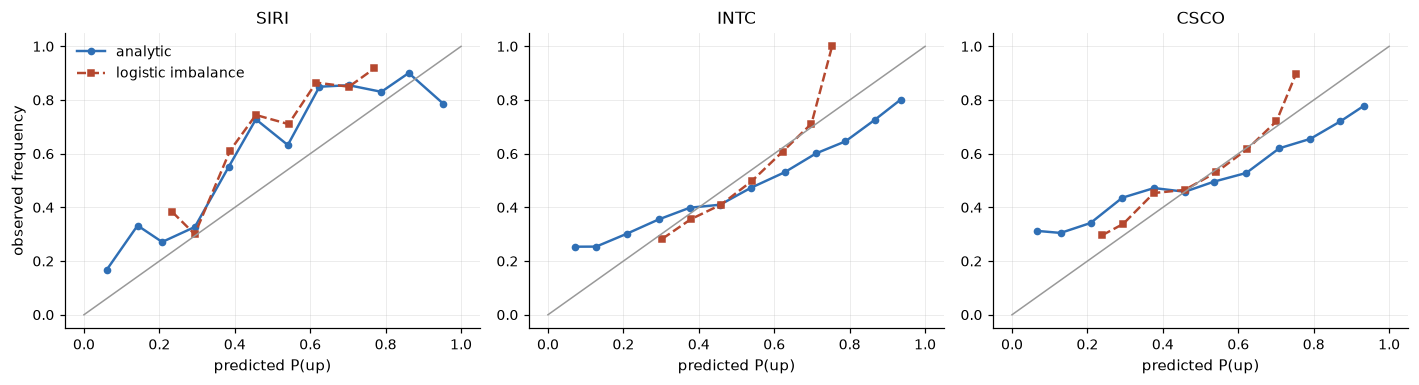

In [6]:
fig, axes = subplots(1, 3, figsize=(13, 3.6))
for ax, sym in zip(axes, ["SIRI", "INTC", "CSCO"]):
    for model, style in [("analytic", "o-"), ("logistic_imbalance", "s--")]:
        c = LC[f"{sym}|{model}|calibration"]
        ok = np.isfinite(c[:, 0])
        ax.plot(c[ok, 0], c[ok, 1], style, ms=4, label=model.replace("_", " "))
    ax.plot([0, 1], [0, 1], color="0.6", lw=1)
    ax.set_title(sym); ax.set_xlabel("predicted P(up)")
axes[0].set_ylabel("observed frequency"); axes[0].legend()
plt.tight_layout()

In [7]:
brier = L[L.scope == "common"].pivot_table(index="symbol", columns="model", values="brier")
print(brier.loc[order, ["analytic", "logistic_imbalance", "logistic_all", "boosted_all"]].round(4).to_string())
worse = (brier["analytic"] > brier["logistic_imbalance"]).sum()
print(f"\nthe never-fitted surface has the worse Brier score on {worse} of "
      f"{len(brier)} symbols, despite matching on AUC")

model   analytic  logistic_imbalance  logistic_all  boosted_all
symbol                                                         
CSCO      0.2493              0.2386        0.2391       0.2505
INTC      0.2434              0.2355        0.2357       0.2417
MU        0.2461              0.2393        0.2395       0.2414
SIRI      0.2164              0.2364        0.2473       0.3552
MSFT      0.2715              0.2461        0.2462       0.2461
AAPL      0.2634              0.2463        0.2456       0.2466
NFLX      0.2784              0.2485        0.2484       0.2509
TSLA      0.2839              0.2491        0.2523       0.2563
REGN      0.2571              0.2474        0.2479       0.2492
ISRG      0.2583              0.2530        0.2523       0.2612
AMZN      0.2771              0.2481        0.2471       0.2487
GOOG      0.2805              0.2478        0.2466       0.2528

the never-fitted surface has the worse Brier score on 11 of 12 symbols, despite matching on AUC


## What the flexible model bought

The signal is essentially one-dimensional — queue imbalance — and a model free to
find interactions in eight features mostly finds ones that do not survive to the
next week.

In [8]:
names = list(np.load(os.path.join("..", "results", "feature_names.npy")))
coef = pd.DataFrame({sym: LC[f"{sym}|coefficients"] for sym in order}, index=names)
print(coef.round(3).to_string())
delta = common["boosted_all"] - common["logistic_imbalance"]
print(f"\nboosted trees minus logistic-on-imbalance: median {delta.median():+.4f}; "
      f"better on {(delta > 0).sum()} of {len(delta)} symbols")

               CSCO   INTC     MU   SIRI   MSFT   AAPL   NFLX   TSLA   REGN   ISRG   AMZN   GOOG
imbalance     0.369  0.599  0.619 -0.049  0.238  0.222  0.035  0.060  0.076  0.043 -0.017  0.007
log_q_bid     0.175 -0.066 -0.043  0.539  0.199  0.040  0.113  0.121  0.183  0.167  0.142  0.137
log_q_ask    -0.177  0.007  0.019 -0.372 -0.262 -0.047 -0.092 -0.094 -0.155 -0.158 -0.089 -0.162
imbalance2   -0.005  0.014  0.025 -0.270  0.026  0.064  0.055  0.056  0.071  0.059  0.043  0.080
spread_ticks -0.008 -0.018 -0.003  0.006  0.003  0.009  0.003 -0.032  0.038  0.010  0.016  0.016
flow_fast     0.008 -0.012 -0.005 -0.025  0.018  0.026  0.031  0.021  0.003 -0.023  0.027  0.004
flow_slow    -0.034 -0.033  0.001  0.050  0.015  0.013  0.035  0.048  0.059  0.096  0.023  0.049
log_since    -0.133  0.013  0.002 -0.098 -0.021  0.013 -0.029  0.023  0.084  0.003 -0.037 -0.017

boosted trees minus logistic-on-imbalance: median -0.0141; better on 2 of 12 symbols


## What this chapter established

The queue-reactive model of chapter 04, fitted only to counts of events against
queue sizes, **ranks the next price move as well as a regression fitted to the
moves themselves**.  Its probabilities, though, are wrong: it is confident where
the data is not.

Predictability tracks the tick, as everything here does.  A stock whose spread is
pinned at one tick carries queues that mean something; a stock whose spread is
fifty ticks carries almost no queue and almost no signal.  Chapter 08 takes the
same signal and asks what it is worth in money.